In [38]:
import numpy as np
import matplotlib.pyplot as plt
from LinearExample import TestLinear



w = np.array([1., 1.])
b = 1.
M = 5

nA = nB = M
margin = 0.5

A, B = TestLinear(w, b, nA, nB, margin, seed=42)
print(f"dim(A): {A.shape}", f"dim(B): {B.shape}", sep='\n')
print(f"sample A:\n{A[:5]}", f"sample B:\n{B[:5]}", sep='\n')

dim(A): (5, 2)
dim(B): (5, 2)
sample A:
[[ 2.21218466  0.86748347]
 [ 2.32653944 -0.56506046]
 [ 1.1275847  -1.42047792]
 [-0.24261157  1.48983033]
 [ 0.19381071  1.25502122]]
sample B:
[[-1.69044037 -0.46239712]
 [ 0.42047792 -2.1275847 ]
 [-2.67296957 -0.76949868]
 [-1.21219595 -1.13600168]
 [-1.3617924  -1.31450386]]


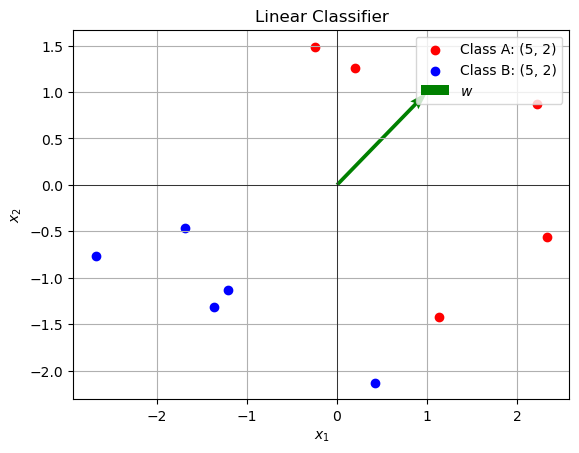

In [40]:
plt.scatter(A[:, 0], A[:, 1], c='r', label=f'Class A: {A.shape}')
plt.scatter(B[:, 0], B[:, 1], c='b', label=f'Class B: {B.shape}')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='g', label='$w$')
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.title('Linear Classifier')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid()
plt.show()

In [41]:
X = np.vstack((A, B))
G = X @ X.T
print(f"dim(X): {X.shape}", f"dim(G): {G.shape}", sep=' | ')

dim(X): (10, 2) | dim(G): (10, 10)


In [ ]:
y = np.hstack((np.ones(nA), -np.ones(nB)))
Y = np.diag(y)

print(f"dim(y): {y.shape}", f"dim(Y): {Y.shape}", sep=' | ')
print(f"y: {y}")

dim(y): (10,) | dim(Y): (10, 10)
y: [ 1.  1.  1.  1.  1. -1. -1. -1. -1. -1.]


In [ ]:
H = Y @ G @ Y 
print(f"dim(H): {H.shape}")

dim(H): (10, 10)


In [56]:
def f(alpha):
    H = Y @ G @ Y    
    return 1/2* alpha.T @ H @ alpha

alpha1 = np.ones(nA + nB)
print(f'dim(alpha1): {alpha1.shape}')

dim(alpha1): (10,)


In [ ]:

class SVM:
    def __init__(self, alpha, C, Y, X, eps = 1e-5):
        self.alpha = alpha
        self.C = C
        self.Y = Y
        self.G = X @ X.T
        self.G_tl = Y @ self.G @ Y
        self.eps = eps
        
        self.delta = 1
        self.lmd = (0.0, np.inf)
        
        
    
    @staticmethod
    def Proj(alpha, grad_f, tau):
        beta = tau*grad_f(alpha)
        return alpha - beta
    

        
    def _alpha(self, lmbd):
        return np.min(C, np.max(0, self.beta + lmbd * self.Y))
    
    def find_lmbd(self):
        eps = self.eps
        lmd_l, lmd_u = self.lmd
        
        while self.Y.T @ self._alpha(lmd_l) > 0:
            lmd_l = lmd_l - self.delta
            lmd_u = lmd_l
        while self.Y.T @ self._alpha(lmd_u) < 0:
            lmd_u = lmd_u + self.delta
            lmd_l = lmd_u
            
        while True:
            lmd_h = (lmd_l + lmd_u) / 2
            f = np.dot(y, self._alpha(lmd_h))
            if abs(f) < self.eps:
                return lmd_h
            elif f < 0:
                lmd_l = lmd_h
            else:
                lmd_u = lmd_h
                
        
        
                
        
        
    
    
    
        
        

Learned w = [1.40148842 1.43198142]
Learned b = 1.3999999999999921
Training Accuracy = 100.00%


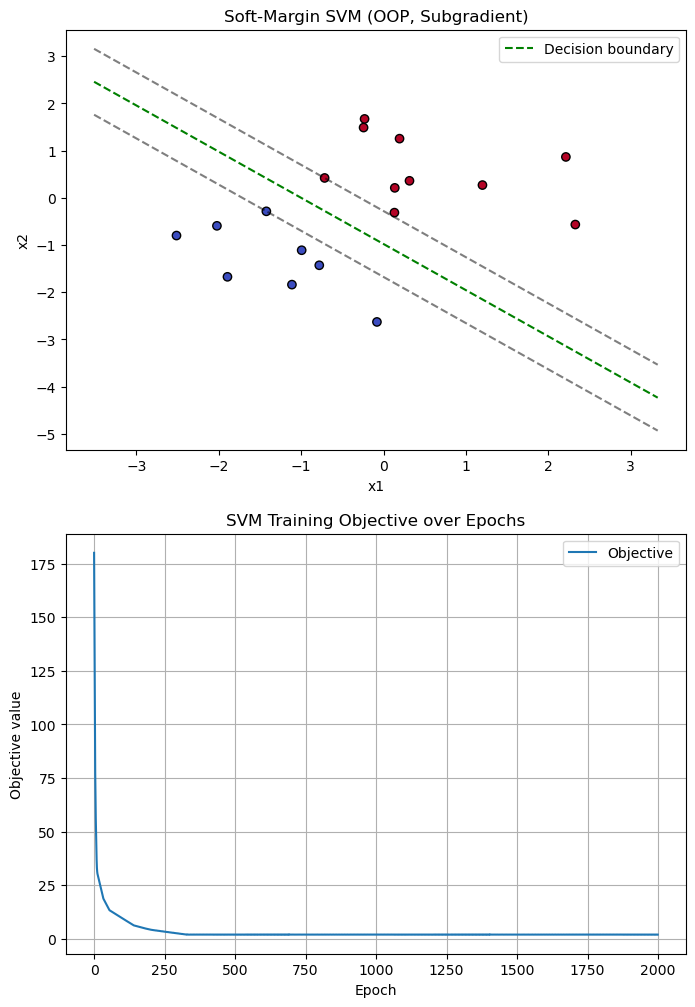

In [2]:

class SVM:
    def __init__(self, C=1.0, max_epochs=1000, lr=0.001):
        """
        Parameters
        ----------
        C: Penalty parameter for misclassified (slack) points.
        max_epochs: Number of passes (epochs) over the training set.
        lr : Fixed learning rate for subgradient steps.
        """
        self.C = C
        self.max_epochs = max_epochs
        self.lr = lr
        
        self.w_ = None  # shape (d,)
        self.b_ = None  # scalar
        
        self.history_ = []

    def fit(self, X, y):
        """
        Fit a linear soft-margin SVM using subgradient descent.

        Parameters
        ----------
        X : shape (d, M) Feature matrix with M samples in d dimensions
        y : shape (M,) Labels in {+1, -1} for each sample

        Returns
        -------
        self : Fitted SVM model
        """
        d, M = X.shape

        # Initialize model parameters
        self.w_ = np.zeros(d)
        self.b_ = 0.0
        self.history_ = []

        for epoch in range(self.max_epochs):
            grad_w = self.w_.copy()
            grad_b = 0.0

            margin = 1 - y * (self.w_ @ X + self.b_)
            active = (margin > 0)

            if np.any(active):
                grad_w -= self.C * np.sum((y[active] * X[:, active]), axis=1)
                grad_b -= self.C * np.sum(y[active])

            self.w_ = self.w_ - self.lr * grad_w
            self.b_ = self.b_ - self.lr * grad_b

            hinge_vals = np.maximum(0.0, margin)
            obj = 0.5 * np.sum(self.w_**2) + self.C * np.sum(hinge_vals)
            self.history_.append(obj)

        return self

    def distance(self, X):
        return self.w_ @ X + self.b_

    def predict(self, X):
        dist = self.distance(X)
        return np.sign(dist)
    
    def plot(self, X, y):
        fig, ax = plt.subplots(2, 1, figsize=(8, 12))
        ax[0].scatter(X[0,:], X[1,:], c=y, cmap='coolwarm', edgecolors='k')
        ax[0].set_title("Data with Labels")
        ax[0].set_xlabel("$x_1$")
        ax[0].set_ylabel("$x_2$")
        ax[0].grid()
        # Decision boundary
        x_min, x_max = X[0,:].min() - 1, X[0,:].max() + 1
        xx = np.linspace(x_min, x_max, 100)
        if abs(self.w_[1]) > 1e-9:
            yy = -(self.b_ + self.w_[0]*xx)/self.w_[1]
            ax[0].plot(xx, yy, 'g--', label="Decision boundary")
            # Margins: w^T x + b = ±1
            yy_plus = -(self.b_ + self.w_[0]*xx - 1)/self.w_[1]
            yy_minus = -(self.b_ + self.w_[0]*xx + 1)/self.w_[1]
            ax[0].plot(xx, yy_plus, 'k--', alpha=0.5)
            ax[0].plot(xx, yy_minus, 'k--', alpha=0.5)
        ax[0].set_title("Soft-Margin SVM (OOP, Subgradient)")
        ax[0].set_xlabel("x1")
        ax[0].set_ylabel("x2")
        ax[0].legend()
        ax[0].grid()
        
        # Plot objective history
        ax[1].plot(self.history_, label="Objective")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Objective value")
        ax[1].set_title("SVM Training Objective over Epochs")
        ax[1].legend()
        ax[1].grid()
        plt.show() 
    
w_gt = np.array([1., 1.])
b_gt = 1.
nA, nB = 10, 8
margin_gt = 0.5

listA, listB = TestLinear(w_gt, b_gt, nA, nB, margin_gt, seed=42)

A = np.array(listA).T  # shape (2, nA)
B = np.array(listB).T  # shape (2, nB)

X = np.concatenate([A, B], axis=1)  # shape (2, nA+nB)
yA = np.ones(nA)
yB = -np.ones(nB)
y = np.concatenate([yA, yB], axis=0)  # shape (nA+nB,)

svm = SVM(C=10.0, max_epochs=2000, lr=0.0005)
svm.fit(X, y)

print("Learned w =", svm.w_)
print("Learned b =", svm.b_)

preds = svm.predict(X)
accuracy = np.mean(preds == y)
print("Training Accuracy = {:.2f}%".format(100*accuracy))

svm.plot(X, y)
